# Nutri Score Analysis

The focus of this analysis lies on the OpenFoodFacts products which Nutri-Score.

Nutri-Score (2023 update) differentiates following food categories:

- **General Food**
  - Cheese
  - Red Meat
- **Fats, Oil, Nuts, Legumes**
- **Beverages**
  - Water

Data used: jsonl.gz dataset (from March 17 2025).

## Data Fields

- `nutrition-score-fr` - outdated
- `nutrition-score-fr_100g` - outdated
- `nutrition_grade_fr` - outdated but seems to reflect latest computed Nutri-Score grade
- `nutrition_grades` - same as `nutrition_grade_fr`
- `nutrition_score_beverage` - outdated?

### Old Nutri-Score (2021) - OUTDATED: Don't use - not all products have this information
- `nutriscore_version`
- `nutriscore_grade`
- `nutriscore_score`
- `nutriscore_data`
- `nutriscore->2021`

### New Nutri-Score (2023)
- `nutriscore->2021|2023`
  - `grade` - grade `A` to `E`
  - `score` - score in product range
  - `category_available` - Nutri-Score needs the food category
  - `nutrients_available` - Nutri-Score needs the nutrition facts
  - `nutriscore_applicable` - Nutri-Score is not applicable to all food products (e.g. baby food)
  - `nutriscore_computed` - same as misc tag? 
  - `data`
    - is_beverage
    - is_cheese
    - is_fat_oil_nuts_seeds
    - is_red_meat_product
    - is_water

### Tags

- misc_tags -> en:nutriscore-computed - which one? all?


## References

- https://www.eurofins.de/food-analysis/other-services/nutri-score/

## Download jsonl.gz snapshot

This will take a couple of minutes

In [1]:
%%time
%%bash
if [ ! -f "openfoodfacts-products.jsonl.gz" ]; then
    curl -L -O https://static.openfoodfacts.org/data/openfoodfacts-products.jsonl.gz;
else
    echo "file already exists. skipping download";
fi

file already exists. skipping download
CPU times: user 2.9 ms, sys: 6.46 ms, total: 9.36 ms
Wall time: 9.74 ms


## Data Extraction - DuckDB

```sql
COPY (
  WITH data AS (
    SELECT *
    FROM read_ndjson(
      'openfoodfacts-products.jsonl.gz', ignore_errors=True,
      columns={
        code:'VARCHAR',
        product_name:'VARCHAR',
        countries_tags: 'VARCHAR[]',
        nutriscore_version:'VARCHAR',
        nutriscore_grade:'VARCHAR',
        nutriscore_score:'INTEGER',
        nutriscore:'STRUCT(
          "2023" STRUCT(
            category_available INTEGER,
            data STRUCT(
              count_proteins INTEGER,
              count_proteins_reason VARCHAR,
              is_beverage BOOLEAN,
              is_cheese BOOLEAN,
              is_fat_oil_nuts_seeds BOOLEAN,
              is_red_meat_product BOOLEAN,
              is_water BOOLEAN,
              negative_points INTEGER,
              negative_points_max INTEGER,
              positive_points INTEGER,
              positive_points_max INTEGER
            ),
            grade VARCHAR,
            nutrients_available INTEGER,
            nutriscore_applicable INTEGER,
            nutriscore_computed INTEGER,
            score INTEGER
          )
        )'
      }
    )
  )
  SELECT
    code,
    product_name,
    array_to_string(countries_tags, ',') AS countries_tags,
    nutriscore_version,
    nutriscore_grade,
    nutriscore_score,
    to_json(nutriscore->'2023') AS nutriscore_2023
  FROM data
) TO 'nutriscore_dd.csv.gz' (FORMAT CSV, HEADER, FORCE_QUOTE (code, product_name));
```

## Data Loading

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [3]:
file_path = "../data/nutriscore_dd.csv.gz"
df = pd.read_csv(file_path, dtype={'code':str})
df = df[df.code.notna()].set_index('code') # exclude empty barcodes

# convert json string to dict
df['nutriscore'] = df.nutriscore_2023.fillna('null').map(json.loads)

# extract Nutri-Score grades
df['grade2023'] = df.nutriscore.map(lambda x: x['grade'] if x else np.nan)

# convert countries tags list
df.countries_tags = df.countries_tags.str.split(',')

# use Int64 for counts with NaN
for col in ['nutriscore_version', 'nutriscore_score']:
    df[col] = df[col].astype('Int64')

display(df)

,product_name,countries_tags,nutriscore_version,nutriscore_grade,nutriscore_score,nutriscore_2023,nutriscore,grade2023
code,,,,,,,,
0000101209159,Véritable pâte à tartiner noisettes chocolat noir,[en:france],2023,e,25,"{""category_available"":1,""data"":{""count_protein...","{'category_available': 1, 'data': {'count_prot...",e
0000105000011,Chamomile Herbal Tea,[en:united-states],2023,unknown,<NA>,"{""category_available"":1,""data"":{""count_protein...","{'category_available': 1, 'data': {'count_prot...",unknown
0000105000042,"Lagg's, herbal tea, peppermint",[en:united-states],2021,unknown,<NA>,"{""category_available"":1,""data"":{""count_protein...","{'category_available': 1, 'data': {'count_prot...",unknown
0000105000059,Linden Flowers Tea,[en:united-states],2023,unknown,<NA>,"{""category_available"":1,""data"":{""count_protein...","{'category_available': 1, 'data': {'count_prot...",unknown
0000105000073,"Herbal Tea, Hibiscus",[en:united-states],2021,unknown,<NA>,"{""category_available"":0,""data"":{""count_protein...","{'category_available': 0, 'data': {'count_prot...",unknown
...,...,...,...,...,...,...,...,...
8718907242424,Sprank Appel,[en:netherlands],2023,unknown,<NA>,"{""category_available"":0,""data"":{""count_protein...","{'category_available': 0, 'data': {'count_prot...",unknown
0007405956277,NaN,[en:belgium],2023,unknown,<NA>,"{""category_available"":0,""data"":{""count_protein...","{'category_available': 0, 'data': {'count_prot...",unknown
3760019590615,NaN,[en:france],<NA>,NaN,<NA>,NaN,None,NaN


### Sanity Check

`nutriscore_grade` is almost the same as `nutriscore`->`2023`->`grade`

In [4]:
same = (df.nutriscore_grade.fillna('NAN') == df.grade2023.fillna('NAN'))
same.value_counts()

True     3753530
False        195
Name: count, dtype: int64

In [5]:
df[~same].nutriscore_version.value_counts(dropna=False)

nutriscore_version
2021    122
<NA>     73
Name: count, dtype: Int64

### Map Country Names to Country Codes

In [6]:
file_path = "../data/country_tag_mapping.csv"
df_cc = pd.read_csv(file_path).set_index("country_tag")
df_cc

,code,flag
country_tag,,
en:france,FR,🇫🇷
en:united-states,US,🇺🇸
en:spain,ES,🇪🇸
en:germany,DE,🇩🇪
en:italy,IT,🇮🇹
...,...,...
en:malaysia-english,MY,🇲🇾
en:nicaragua-espanol,NI,🇳🇮
en:panama-espanol,PA,🇵🇦


In [7]:
code_lookup = df_cc['code'].to_dict()

def toCountryCode(tags: list):
    if isinstance(tags, list):
        return [code_lookup[tag] for tag in tags if tag in code_lookup]
    else:
        return None
    
df['cc'] = df['countries_tags'].apply(toCountryCode)

## Data Analysis

In [8]:
# Annotate each horizontal bar with its value
def annotate_hbars(ax, total: int):
    for bar in ax.patches:
        width = bar.get_width()
        ax.text(width + 1, bar.get_y() + bar.get_height() / 2,
            f' {int(width):,}\n ({width / total * 100:.1f}%)', va='center', ha='left', fontsize=8)

The field `nutriscore_version` should be ignored. It seems to be outdated and does not match the data in the `nutriscore` field. Basically all products have version 2023.

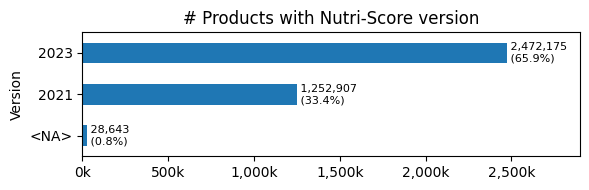

In [9]:
ax = df.nutriscore_version.value_counts(dropna=False).plot.barh(figsize=(6, 2))
ax.xaxis.set_major_formatter(lambda x, pos: f'{int(x/1000):,}k')
ax.invert_yaxis()
ax.set_ylabel('Version')

annotate_hbars(ax, len(df))
plt.xlim(0, 2.9e6)

plt.title('# Products with Nutri-Score version')
plt.tight_layout()

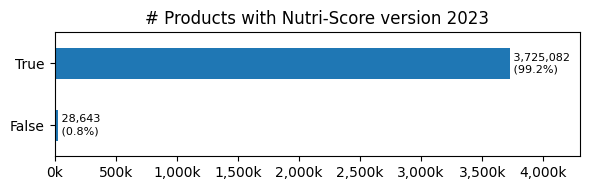

In [10]:
ax = df.nutriscore_2023.notna().value_counts(dropna=False).plot.barh(figsize=(6, 2))
ax.xaxis.set_major_formatter(lambda x, pos: f'{int(x/1000):,}k')
ax.invert_yaxis()
ax.set_ylabel(None)

annotate_hbars(ax, len(df))
plt.xlim(0, 4.3e6)

plt.title('# Products with Nutri-Score version 2023')
plt.tight_layout()

## Nutri-Score 2023 Grades

In [11]:
nutricol = {
    'dark_green':  '#008f00',  # C=100, M=25, Y=100
    'lime_green':  '#56bf00',  # C=55,  M=25, Y=100
    'yellow':      '#FFCC00',  # M=20,  Y=100
    # 'orange':      '#FF6600',  # M=60,  Y=100
    'orange':      '#FF7700',
    'red':         '#FF1900',  # M=90,  Y=100
}

fullcol = [*nutricol.values(), 'black', '#ddd', 'grey']

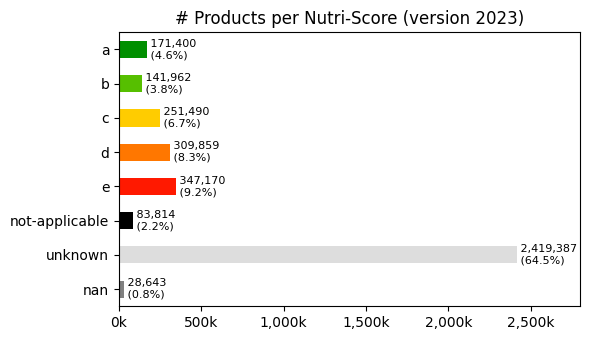

In [12]:
ax = df.grade2023.value_counts(dropna=False).sort_index().plot.barh(color=fullcol, figsize=(6, 3.5))
ax.xaxis.set_major_formatter(lambda x, pos: f'{int(x/1000):,}k')
ax.invert_yaxis()
ax.set_ylabel(None)

annotate_hbars(ax, len(df))
plt.xlim(0, 2.8e6)

plt.title('# Products per Nutri-Score (version 2023)')
plt.tight_layout()

## Per Country

In [13]:
cols = ['cc', 'grade2023']
grouped = (
  df[cols]
  .dropna(subset=['grade2023'])
  .explode('cc')
  .dropna(subset=['cc'])
  .groupby(cols, dropna=False)
  .size()
  .unstack()
  .fillna(0)
  .astype(int)
)
grouped.columns = grouped.columns.where(grouped.columns.notna(), 'N/A')

top_countries = grouped.sum(axis=1).sort_values(ascending=False).index
top_df = grouped.loc[top_countries]#.reindex(columns=[*age_categories, 'N/A'])

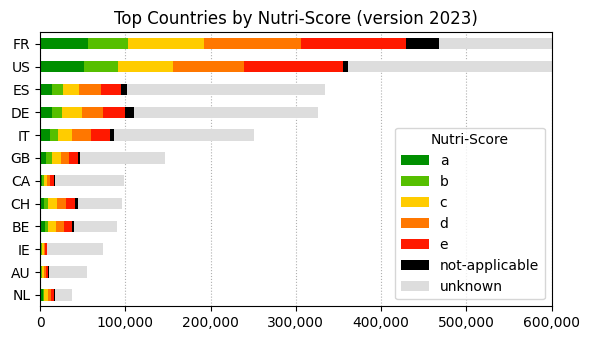

In [14]:
fig, ax = plt.subplots(figsize=(6, 3.5))
top_df[:12].plot.barh(stacked=True, ax=ax, color=fullcol)

ax.invert_yaxis()
ax.set_ylabel(None)
ax.xaxis.set_major_formatter(lambda x, pos: f'{int(x):,}')
ax.set_xlim(0, 6e5)

ax.set_axisbelow(True)
plt.grid(axis='x', linestyle=':', linewidth=0.8)
plt.legend(title="Nutri-Score")
plt.title('Top Countries by Nutri-Score (version 2023)')
plt.tight_layout()

### State Flags

Nutri-Score computation needs as input
- food category
- nutrition facts
- ingredients

If one of these are missing, the Nutri-Score cannot be computed. Also, Nutri-Score is not applicable for all food products (e.g. baby food).

-> State flags indicate 
- need category to know if Nutri-Score is applicable or not
- many products without Nutri-Score - seems like ingredients, nutrition values or category are missing

In [15]:
states2023 = df.nutriscore.apply(lambda x: ", ".join([k.replace('nutriscore_', '') for k, v in x.items() if k.startswith('nutriscore_') and v]) if x != None else None)
df_cross_states = pd.crosstab(states2023, df.grade2023, dropna=True)

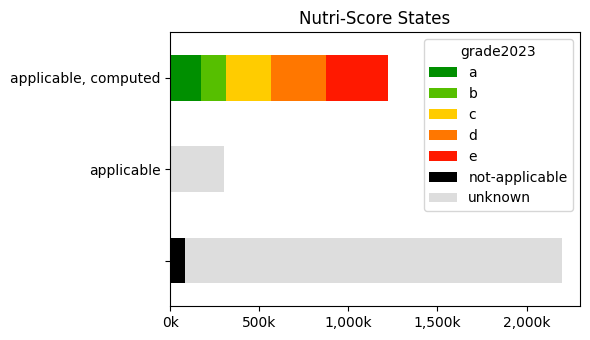

In [16]:
ax = df_cross_states.plot.barh(stacked=True, figsize=(6, 3.5), color=fullcol)
ax.xaxis.set_major_formatter(lambda x, pos: f'{int(x/1000):,}k')
ax.set_ylabel(None)
ax.set_xlim(0, 2.3e6)

plt.title('Nutri-Score States')
plt.tight_layout()

In [17]:
available2023 = df.nutriscore.apply(lambda x: ", ".join([k.replace('_available', '') for k, v in x.items() if k.endswith('_available') and v]) if x != None else None)
df_cross_avail = pd.crosstab(available2023, df.grade2023, dropna=True)

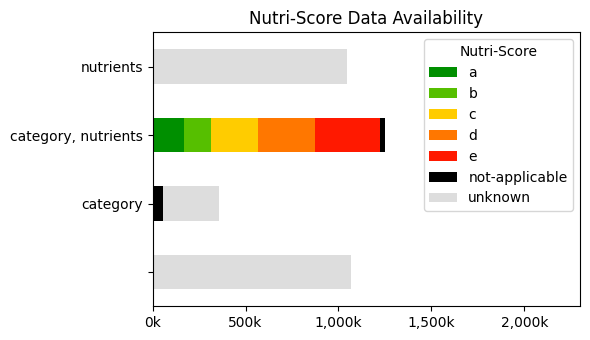

In [18]:
ax = df_cross_avail.plot.barh(stacked=True, figsize=(6, 3.5), color=fullcol)
ax.xaxis.set_major_formatter(lambda x, pos: f'{int(x/1000):,}k')
ax.set_ylabel(None)
ax.set_xlim(0, 2.3e6)

plt.title('Nutri-Score Data Availability')
plt.legend(title='Nutri-Score')
plt.tight_layout()

!!! The states don't differentiate between "not applicable" and "unknown if applicable".
1. category is unknown -> unclear if applicable
2. category is known but not applicable -> also no applicable tag

- applicable + computed -> has Nutri-Score
- applicable, not computed -> has category but not nutrients
- no state -> unknown why -> need to look at nutri score and available data

Approach it rather the other way around:
1. look at available data, then check if applicable and computed

In [19]:
df_cross_states_avail = pd.crosstab(available2023, states2023, dropna=True)

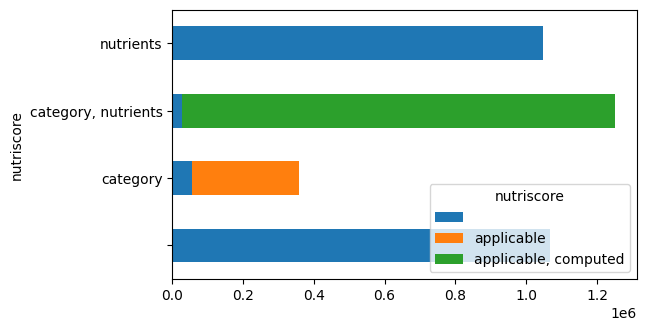

In [20]:
ax = df_cross_states_avail.plot.barh(stacked=True, figsize=(6, 3.5))

### Scores

In [21]:
df.nutriscore_score.notna().value_counts(dropna=False).sort_index().map("{:,}".format)

nutriscore_score
False    2,531,769
True     1,221,956
Name: count, dtype: object

In [22]:
df.nutriscore.map(lambda x: x['score'] if x else None).notna().value_counts().map("{:,}".format)

nutriscore
False    2,531,844
True     1,221,881
Name: count, dtype: object

<Axes: xlabel='nutriscore_score'>

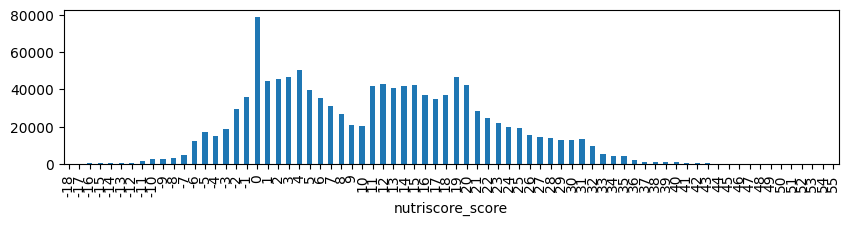

In [23]:
df.nutriscore_score.value_counts().sort_index().plot.bar(figsize=(10, 2))

<Axes: xlabel='nutriscore'>

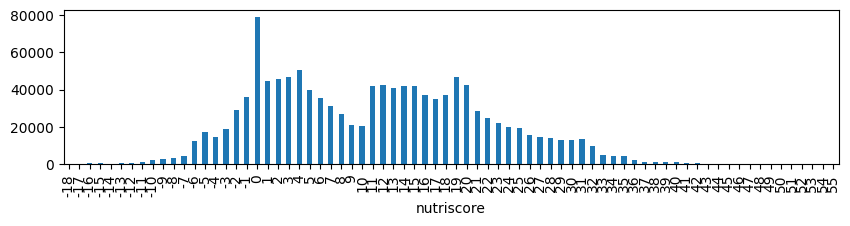

In [24]:
df.nutriscore.dropna().map(lambda x: x['score']).dropna().astype(int).value_counts().sort_index().plot.bar(figsize=(10, 2))

### Keys

In [25]:
# get all keys starting with 'is_' and having a value of True
cats = df.nutriscore.apply(lambda x: ", ".join([k for k, v in x['data'].items() if k.startswith('is_') and v]) if x != None else None)

In [26]:
cats.value_counts(dropna=False).map("{:,}".format)

nutriscore
                                                         3,281,012
is_beverage                                                211,992
is_fat_oil_nuts_seeds                                       90,874
is_cheese                                                   74,590
is_red_meat_product                                         59,956
None                                                        28,643
is_beverage, is_water                                        5,816
is_cheese, is_red_meat_product                                 394
is_beverage, is_fat_oil_nuts_seeds                             201
is_fat_oil_nuts_seeds, is_red_meat_product                      85
is_cheese, is_fat_oil_nuts_seeds                                76
is_beverage, is_cheese                                          60
is_beverage, is_red_meat_product                                21
is_beverage, is_cheese, is_water                                 2
is_beverage, is_fat_oil_nuts_seeds, is_water       

### Plotting Function

In [27]:
general_limits = [0, 2, 10, 18]
general_labels = ['A (<=0)', 'B (1-2)', 'C (3-10)', 'D (11-18)', 'E (>=19)']
fatoilnuts_limits = [-6, 2, 10, 18]
fatoilnuts_labels = ['A (<=-6)', 'B (-5-2)', 'C (3-10)', 'D (11-18)', 'E (>=19)']
beverage_limits = [-100, 2, 6, 9]
beverage_labels = ['A waters', 'B (<=2)', 'C (3-6)', 'D (7-9)', 'E (>=10)']
waters_limits = [0, 2, 6, 9]

def plot_nutri(scores: pd.Series, min: int, max: int, limits: list, colors: list, labels: list = None, title: str = None):
  bins = np.arange(min-0.5, max+0.51, 1)
  fig, ax = plt.subplots(figsize=(6,3.5))
  scores.dropna().plot.hist(bins=bins, ax=ax)
  
  ax.yaxis.set_major_formatter(lambda y, pos: f'{int(y):,}')
  ax.set_ylabel('# of Products')
  ax.set_xlabel('Score')
  ax.set_title(f"{title}\n({len(scores):,} products)")

  legend_handles = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, labels)]
  ax.legend(handles=legend_handles, title='Nutri-Score', loc='upper right')

  # Iterate over each bar (patch) in the histogram
  for patch in ax.patches:
    # Get the left edge and width of the bin to calculate its center
    x = patch.get_x()
    width = patch.get_width()
    center = x + width / 2

    # iterate with index over limits
    for i, limit in enumerate(limits):
      if center <= limit:
        patch.set_facecolor(colors[i])
        break;
      else:
        patch.set_facecolor(colors[-1])

  # show min and max
  ax.axvline(min-0.5, color='grey', linestyle=':')
  ax.axvline(max+0.5, color='grey', linestyle=':')

  ax.annotate(f"min: {min}",
                  xytext=(0.01, -0.22), textcoords='axes fraction',
                  xy=(min-0.5, 0), xycoords='data',
                  size=9, va="center", ha="left",
                  bbox=dict(boxstyle="square", fc="w", pad=0.3),
                  arrowprops=dict(arrowstyle="->",
                                  connectionstyle="arc3,rad=0.2",
                                  fc="w"))
  ax.annotate(f"max: {max}",
                  xytext=(0.85, -0.22), textcoords='axes fraction',
                  xy=(max+0.5, 0), xycoords='data',
                  size=9, va="center", ha="left",
                  bbox=dict(boxstyle="square", fc="w", pad=0.3),
                  arrowprops=dict(arrowstyle="->",
                                  connectionstyle="arc3,rad=-0.2",
                                  fc="w"))
  plt.tight_layout()
  return fig

## Score Distribution

In [28]:
general_scores = df[cats.map(lambda x: -1 if x == None else len(x)) == 0].nutriscore_score
general_scores.describe()

count     910473.0
mean     12.011904
std      10.572237
min          -17.0
25%            3.0
50%           12.0
75%           20.0
max           55.0
Name: nutriscore_score, dtype: Float64

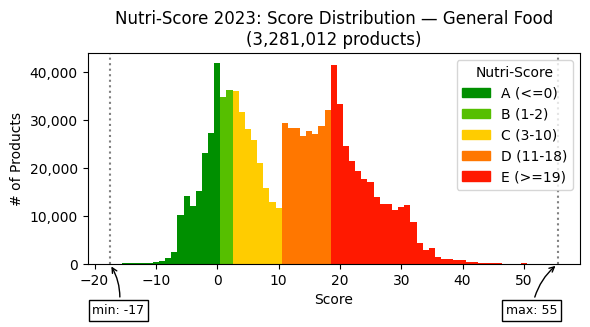

In [29]:
fig = plot_nutri(general_scores, -17, 55, general_limits, list(nutricol.values()), general_labels, title='Nutri-Score 2023: Score Distribution — General Food')
fig.savefig("nutriscore_general.png")

In [30]:
# only is_cheese
cheese_scores = df[cats.eq('is_cheese')].nutriscore_score
cheese_scores.describe()

count      63755.0
mean     13.633958
std       5.087275
min           -8.0
25%           11.0
50%           14.0
75%           16.0
max           41.0
Name: nutriscore_score, dtype: Float64

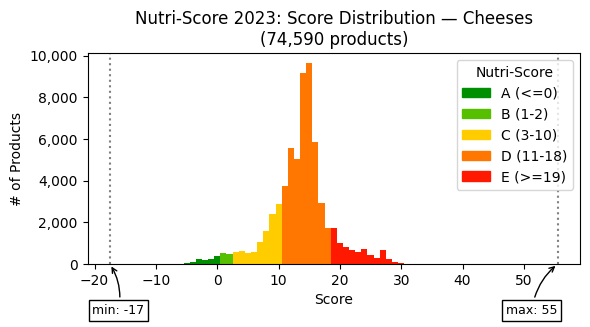

In [31]:
fig = plot_nutri(cheese_scores, -17, 55, general_limits, list(nutricol.values()), general_labels, title='Nutri-Score 2023: Score Distribution — Cheeses')
fig.savefig("nutriscore_cheeses.png")

In [32]:
# only red meat products
redmeat_scores = df[cats.eq('is_red_meat_product')].nutriscore_score
redmeat_scores.describe()

count      48025.0
mean     15.952795
std       9.853466
min           -7.0
25%            7.0
50%           16.0
75%           23.0
max           48.0
Name: nutriscore_score, dtype: Float64

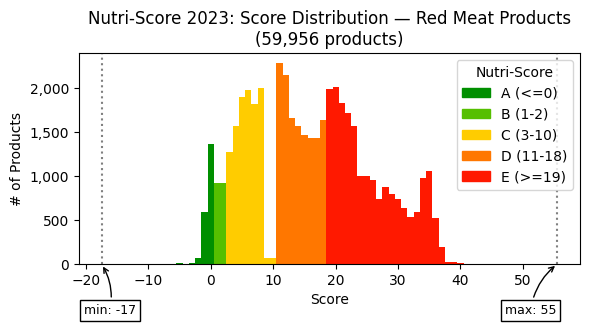

In [33]:
fig = plot_nutri(redmeat_scores, -17, 55, general_limits, list(nutricol.values()), general_labels, title='Nutri-Score 2023: Score Distribution — Red Meat Products')
fig.savefig("nutriscore_red_meat.png")

In [34]:
# only is_fat_oil_nuts_seeds
fatoilnuts_scores = df[cats.eq('is_fat_oil_nuts_seeds')].nutriscore_score
fatoilnuts_scores.describe()

count     73133.0
mean     3.301998
std       9.52525
min         -17.0
25%          -3.0
50%           1.0
75%           9.0
max          53.0
Name: nutriscore_score, dtype: Float64

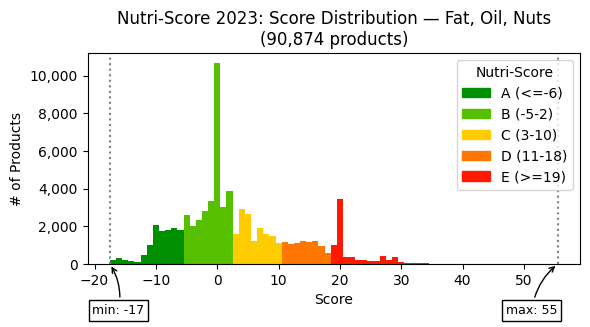

In [35]:
fig = plot_nutri(fatoilnuts_scores, -17, 55, fatoilnuts_limits, list(nutricol.values()), fatoilnuts_labels, title='Nutri-Score 2023: Score Distribution — Fat, Oil, Nuts')
fig.savefig("nutriscore_fatoilnuts.png")

In [36]:
# only beverages
beverage_scores = df[cats.eq('is_beverage')].nutriscore_score
beverage_scores.describe()

count    120025.0
mean     6.410848
std      6.541316
min         -18.0
25%           1.0
50%           5.0
75%          11.0
max          54.0
Name: nutriscore_score, dtype: Float64

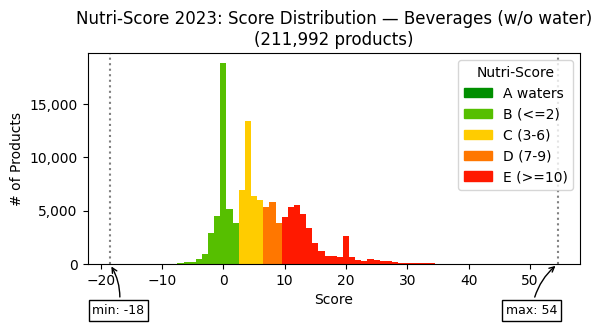

In [37]:
fig = plot_nutri(beverage_scores, -18, 54, beverage_limits, list(nutricol.values()), beverage_labels, title='Nutri-Score 2023: Score Distribution — Beverages (w/o water)')
fig.savefig("nutriscore_beverages.png")

In [38]:
# only water
water_scores = df[cats.eq('is_beverage, is_water')].nutriscore_score
water_scores.describe()

count      5799.0
mean     0.254009
std      1.876804
min          -7.0
25%           0.0
50%           0.0
75%           0.0
max          25.0
Name: nutriscore_score, dtype: Float64

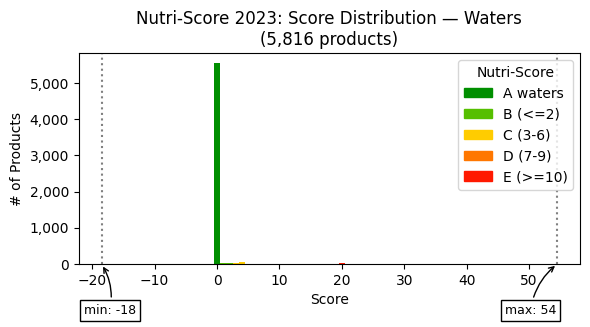

In [39]:
fig = plot_nutri(water_scores, -18, 54, waters_limits, list(nutricol.values()), beverage_labels, title='Nutri-Score 2023: Score Distribution — Waters')
fig.savefig("nutriscore_waters.png")

## Product Analysis

In [40]:
beverage_scores.dropna().sort_values()#.tail(600)

code
03345302         -18
3770029889029    -18
4010355009791    -14
3388742800117    -14
3000013060005    -12
                ... 
0098487201546     48
8888522019524     49
0658325575545     49
0021600105629     49
0078742354828     54
Name: nutriscore_score, Length: 120025, dtype: Int64

In [41]:
df.product_name[beverage_scores.dropna().sort_values().index]

code
03345302                              Lupinen Kaffee
3770029889029                            Lupi Coffee
4010355009791                             Salbei Tee
3388742800117    Tisanes de sauge bio - Romon Nature
3000013060005                       Fleurs de gwozey
                                ...                 
0098487201546                             Cappuccino
8888522019524               Matcha Latte - Green Tea
0658325575545                Rooibos Latté Classique
0021600105629          Caramel Cappucciono Drink Mix
0078742354828                             Chai Latte
Name: product_name, Length: 120026, dtype: object

In [42]:
fatoilnuts_scores.dropna().sort_values()

code
0071754410006    -17
0039970004239    -17
3398240007215    -17
3347430022170    -17
5601255110169    -17
                ... 
0739944007249     45
3780568801505     47
6111092000176     48
3400938267266     50
4823085718549     53
Name: nutriscore_score, Length: 73133, dtype: Int64

In [43]:
df.product_name[fatoilnuts_scores.dropna().sort_values().index].tail(30)

code
3760275580115                                 Beurre de la ferme demi sel
0742392930298             Usda organic grass fed ghee with himalayan salt
4032108120102                                                  Cocos ghee
13251212512000002752    Beurre AOP La Viette Motte Panier Bois ½ Sel -...
0036800457058                               Organic Ghee clarified butter
5411873132609                                              Beurre du pays
4034900004963                                               Kräuterbutter
8410128000554                                                 Mantequilla
13251212512000002680       Beurre De Savenay 1/2 Sel En Plaquette De 500g
13251212512000002824    Beurre Fermier Demi Sel - Au Sel De Guérande B...
13251212512000014703     Beurre Demi-sel La Conviette AOP 15g X 30 Pièces
0011110036988                               Ghee with pink himalayan salt
9421904202009                                         Coconut cooking oil
0860002133782                    

### Score Translation

In [44]:
base = 2

for min_val in [-7, -6, -5.5, -4]:
  scaling_factor = (75-90) / (min_val - base)
  max_val = 75 / scaling_factor + base
  print(f"---Min: {min_val} (factor: {scaling_factor}), Max: {max_val}")
  
  for i in [min_val, 0, 2, 10, 18, max_val]:
    pct = 75 - (i - base) * scaling_factor
    print(f"Score: {i}, Pct: {pct:.2f}")

---Min: -7 (factor: 1.6666666666666667), Max: 47.0
Score: -7, Pct: 90.00
Score: 0, Pct: 78.33
Score: 2, Pct: 75.00
Score: 10, Pct: 61.67
Score: 18, Pct: 48.33
Score: 47.0, Pct: 0.00
---Min: -6 (factor: 1.875), Max: 42.0
Score: -6, Pct: 90.00
Score: 0, Pct: 78.75
Score: 2, Pct: 75.00
Score: 10, Pct: 60.00
Score: 18, Pct: 45.00
Score: 42.0, Pct: 0.00
---Min: -5.5 (factor: 2.0), Max: 39.5
Score: -5.5, Pct: 90.00
Score: 0, Pct: 79.00
Score: 2, Pct: 75.00
Score: 10, Pct: 59.00
Score: 18, Pct: 43.00
Score: 39.5, Pct: 0.00
---Min: -4 (factor: 2.5), Max: 32.0
Score: -4, Pct: 90.00
Score: 0, Pct: 80.00
Score: 2, Pct: 75.00
Score: 10, Pct: 55.00
Score: 18, Pct: 35.00
Score: 32.0, Pct: 0.00


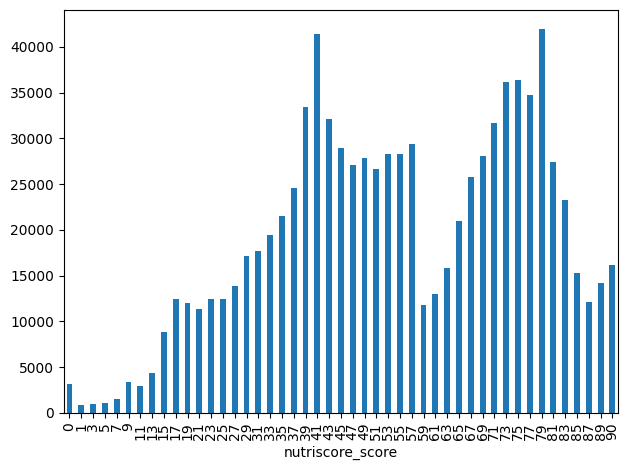

In [45]:
general_scores.dropna().map(lambda x: max(0, min(90, 75 - (x - base) * 2))).astype(int).value_counts().sort_index().plot.bar()#.map("{:,}".format)
plt.tight_layout()

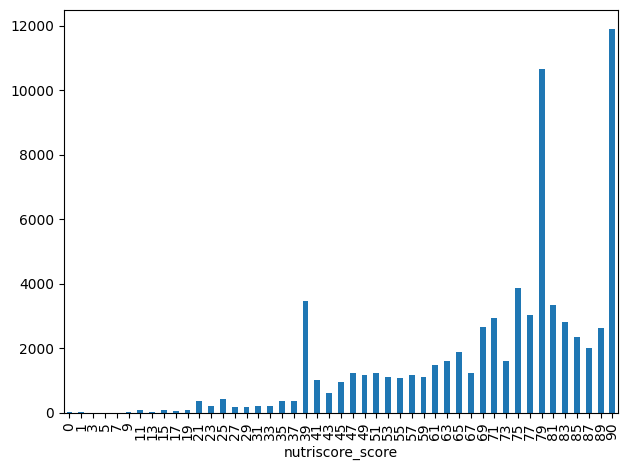

In [46]:
fatoilnuts_scores.dropna().map(lambda x: max(0, min(90, 75 - (x - base) * 2))).astype(int).value_counts().sort_index().plot.bar()
plt.tight_layout()

In [47]:
base = 2

for min_val in [-4, -3, -2]:
  scaling_factor = (75-90) / (min_val - base)
  max_val = 75 / scaling_factor + base
  print(f"---Min: {min_val} (factor: {scaling_factor}), Max: {max_val}")

  for i in [min_val, 2, 6, 9, max_val]:
    pct = 75 - (i - base) * scaling_factor
    print(f"Score: {i}, Pct: {pct:.2f}")

---Min: -4 (factor: 2.5), Max: 32.0
Score: -4, Pct: 90.00
Score: 2, Pct: 75.00
Score: 6, Pct: 65.00
Score: 9, Pct: 57.50
Score: 32.0, Pct: 0.00
---Min: -3 (factor: 3.0), Max: 27.0
Score: -3, Pct: 90.00
Score: 2, Pct: 75.00
Score: 6, Pct: 63.00
Score: 9, Pct: 54.00
Score: 27.0, Pct: 0.00
---Min: -2 (factor: 3.75), Max: 22.0
Score: -2, Pct: 90.00
Score: 2, Pct: 75.00
Score: 6, Pct: 60.00
Score: 9, Pct: 48.75
Score: 22.0, Pct: 0.00


<Axes: xlabel='nutriscore_score'>

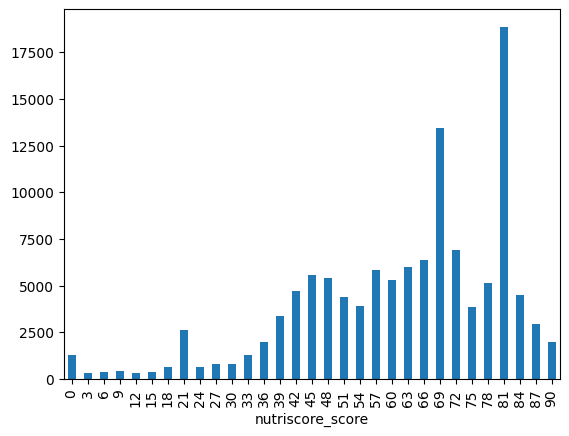

In [48]:
beverage_scores.dropna().map(lambda x: max(0, min(90, 75 - (x - base) * 3))).astype(int).value_counts().sort_index().plot.bar()